This notebook presents some of the figures generated for the analysis of sections with multiple measurements in time

In [5]:
import pandas as pd
import sqlite3
import os
from pathlib import Path
import numpy as np
import seaborn as sns
import peewee as pw
import matplotlib.pyplot as plt
import sklearn as skl

#swithc working directory to 
os.chdir(r'c:\Repositories\asphalt-db')
from main.data_classifications import *
from main.data_processing import *
from src.db_builder.models import *
from main.query_database import *

sns.set_style('whitegrid')
working_dir = Path(r'c:\Repositories\asphalt-db\results')
results_dir = Path(r'c:\Users\klerk_wj\OneDrive - Stichting Deltares\00_Projecten\09_Kvk Asfalt\results')

## Wat voorspellen we?

In [6]:
#load the data
dikes_and_projects = query_dikes_and_projects(sqlite3.connect(working_dir.parent.joinpath('data','database_all_v3.sqlite')))
df_final = load_and_merge_data(working_dir.parent.joinpath('data','database_all_v3.sqlite'))
data_per_dike_project = get_section_based_statistics(df_final, dikes_and_projects)
df_final, data_per_dike_project = classifications_wrapper(df_final, data_per_dike_project)


In [7]:
unique_sections = data_per_dike_project.dike_name.unique()
#find pattern: name_with_underscores_number - number
import re
pattern = re.compile(r'^(.*)_(\d+,\d+)\s*-\s*(\d+,\d+)$')
#store in dict with name, start, end
section_bounds = {}
for section in unique_sections:
    match = pattern.match(section)
    if match:
        name = match.group(1)
        start = float(match.group(2).replace(',', '.'))
        end = float(match.group(3).replace(',', '.'))
        section_bounds[section] = (start, end)

#get all start and end values in a list, and also the keys = []
sections_lengths = []
for key, (start, end) in section_bounds.items():
    sections_lengths.append((key, np.abs(end - start)))

#make dataframe from sections_lengths
sections_lengths_df = pd.DataFrame(sections_lengths, columns=['dike_name', 'length'])

In [8]:
#merge to data_per_dike_project
data_per_dike_project = data_per_dike_project.merge(sections_lengths_df, on='dike_name', how='left')



Text(0, 0.5, 'Standaardafwijking buigtreksterkte (MPa)')

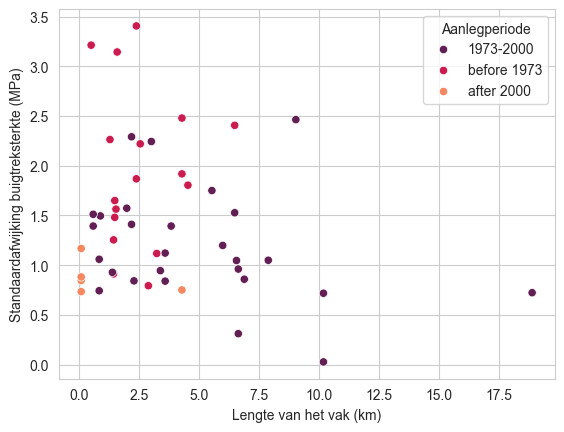

In [9]:
#scatterplot of length vs sig_b_cov, colored by heterogeneity_category
sns.scatterplot(data=data_per_dike_project.rename(columns={'construction_year_category': 'Aanlegperiode'}), x='length', y='sig_b_std', hue='Aanlegperiode',palette='rocket')
plt.xlabel('Lengte van het vak (km)')
plt.ylabel('Standaardafwijking buigtreksterkte (MPa)')

In [10]:
# pd.DataFrame(df_final.dike_name.unique(), columns=['dike_name']).to_excel(working_dir.joinpath('dike_names.xlsx'), index=False)
#load the matrix of dike names and whether they are connected or not (1 means connected)
dike_connections = pd.read_excel(working_dir.parent.joinpath('data','dike_connections.xlsx'))
dike_connections.set_index('dike_name', inplace=True)
#make a list of dike names and the number of corresponding dike_names by summing by row
dike_connections['num_connections'] = dike_connections.sum(axis=1)

In [11]:
import numpy as np
dike_connections[['num_connections']].sort_values('num_connections', ascending=False).head(10)

#for each dike_name in dike_connections where num_connections > 1: select the data from df_final where dike_name is that dike_name or any of the connected dike_names
#make a list of the index such that we can pop the sections already plotted
plotted_for = [] 
dike_list = dike_connections.index.tolist()
#also make a list of dike_names where there are multiple project_id's for the same dike_name
multiple_projects = dikes_and_projects.groupby('dike_name')['project_id'].nunique()
multiple_projects = multiple_projects[multiple_projects > 1].index.tolist()
results_dir.joinpath(f'timeseries_per_section_HR').mkdir(parents=True, exist_ok=True)
for count, dike in enumerate(dike_list):
    if (dike_connections.loc[dike, 'num_connections'] > 1) or (dike in multiple_projects):
        connected_dikes = dike_connections.columns[dike_connections.loc[dike] == 1].tolist()
        dike_data = df_final[df_final['dike_name'].isin(connected_dikes + [dike])]
        #make a scatterplot of age_at_investigation vs sig_b, colored by dike_name
        fig, ax = plt.subplots(figsize=(6,6))
        #add age_since_first_investigation column
        dike_data['age_since_first_investigation'] = dike_data['age_at_investigation'] - dike_data['age_at_investigation'].min()
        #add boxplot for each of the unique values of age_at_investigation, make sure that boxplots align on x-axis
        sns.boxplot(data=dike_data, x='age_at_investigation', y='HR', ax=ax, color='lightgray', fliersize=1, width=2, positions=sorted(dike_data['age_at_investigation'].unique()),zorder=1)
        sns.scatterplot(data=dike_data, x='age_at_investigation', y='HR', hue='dike_name', palette='tab10',ax=ax,zorder=1000)
        sns.regplot(data=dike_data, x='age_at_investigation', y='HR', ci=None, scatter=False, ax=ax, color='gray')
        # sns.boxplot(data=dike_data, x='age_at_investigation', y='sig_b', ax=ax, color='lightgray', fliersize=0, width=0.5)   

        ax.set_title(f'Data for {dike} and connected dikes')
        ax.set_xlabel('Leeftijd bij onderzoek (jaar)')
        # ax.set_ylabel('Buigtreksterkte (MPa)')
        ax.set_ylabel('Holle ruimte  (%)')
        ax.set_xlim(np.floor(dike_data.age_at_investigation.min()/10)*10, np.ceil(dike_data.age_at_investigation.max()/10)*10)
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        #fix x_ticks to be integers at the right positions
        ax.set_xticks(sorted(dike_data['age_at_investigation'].unique()))
        ax.set_xticklabels([str(int(x)) for x in sorted(dike_data['age_at_investigation'].unique())])
        plt.savefig(results_dir.joinpath(f'timeseries_per_section_HR/{dike}_and_connected_dikes.png'), bbox_inches='tight')
        plt.close()

        plotted_for.append((dike, len(connected_dikes)))
        #pop the dike and connected dikes from the dike_list
        for cd in connected_dikes:
            if cd in dike_list:
                dike_list.remove(cd)

#print table with name and number of connected dikes

pd.DataFrame(plotted_for, columns=['dike_name', 'num_connected_dikes']).to_csv(results_dir.joinpath('timeseries_per_section','plotted_dike_sections.csv'), index=False)

C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_32040\1990128360.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dike_data['age_since_first_investigation'] = dike_data['age_at_investigation'] - dike_data['age_at_investigation'].min()
C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_32040\1990128360.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dike_data['age_since_first_investigation'] = dike_data['age_at_investigation'] - dike_data['age_at_investigation'].min()
C:\Users\klerk_wj\AppData\Local\Temp

C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_32040\1443592040.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dike_data['age_since_first_investigation'] = dike_data['age_at_investigation'] - dike_data['age_at_investigation'].min()
C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_32040\1443592040.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dike_data['age_since_first_investigation'] = dike_data['age_at_investigation'] - dike_data['age_at_investigation'].min()
C:\Users\klerk_wj\AppData\Local\Temp

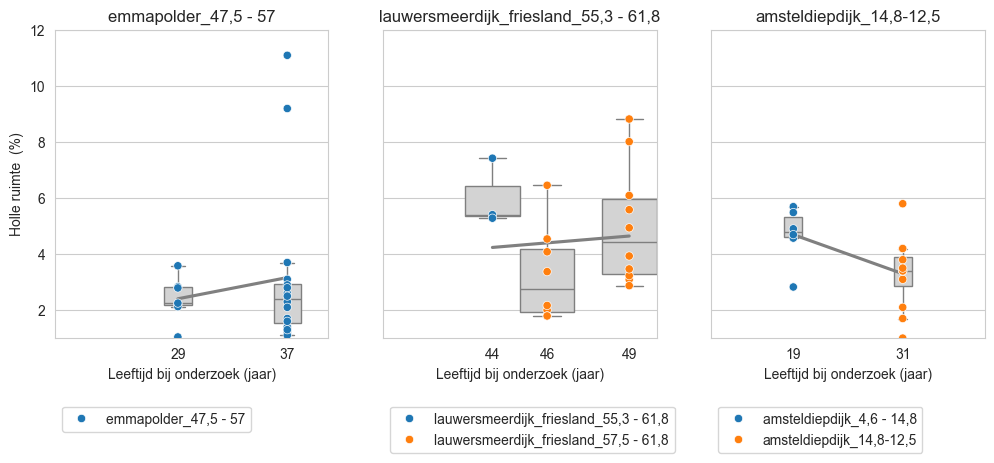

In [12]:
subset = [ 'emmapolder_47,5 - 57',
 'lauwersmeerdijk_friesland_55,3 - 61,8',
 'amsteldiepdijk_14,8-12,5',]
fig, ax = plt.subplots(figsize=(12,4), ncols=3)
for count, dike in enumerate(subset):
    if (dike_connections.loc[dike, 'num_connections'] > 1) or (dike in multiple_projects):
        connected_dikes = dike_connections.columns[dike_connections.loc[dike] == 1].tolist()
        dike_data = df_final[df_final['dike_name'].isin(connected_dikes + [dike])]
        #make a scatterplot of age_at_investigation vs sig_b, colored by dike_name
        #add age_since_first_investigation column
        dike_data['age_since_first_investigation'] = dike_data['age_at_investigation'] - dike_data['age_at_investigation'].min()
        #add boxplot for each of the unique values of age_at_investigation, make sure that boxplots align on x-axis
        sns.boxplot(data=dike_data, x='age_at_investigation', y='HR', ax=ax[count], color='lightgray', fliersize=1, width=2, positions=sorted(dike_data['age_at_investigation'].unique()),zorder=1)
        sns.scatterplot(data=dike_data, x='age_at_investigation', y='HR', hue='dike_name', palette='tab10',ax=ax[count],zorder=1000)
        sns.regplot(data=dike_data, x='age_at_investigation', y='HR', ci=None, scatter=False, ax=ax[count], color='gray')
        # sns.boxplot(data=dike_data, x='age_at_investigation', y='sig_b', ax=ax, color='lightgray', fliersize=0, width=0.5)   

        ax[count].set_title(f'{dike}')
        ax[count].set_xlabel('Leeftijd bij onderzoek (jaar)')
        # ax.set_ylabel('Buigtreksterkte (MPa)')`
        if count == 0:
            ax[count].set_ylabel('Holle ruimte  (%)')
        else:
            ax[count].set_ylabel('')
            ax[count].set_yticklabels([])
        ax[count].set_xlim(np.floor(dike_data.age_at_investigation.min()/10)*10, np.ceil(dike_data.age_at_investigation.max()/10)*10)
        ax[count].legend(bbox_to_anchor=(0, -.20), loc='upper left')
        #fix x_ticks to be integers at the right positions
        ax[count].set_xticks(sorted(dike_data['age_at_investigation'].unique()))
        ax[count].set_xticklabels([str(int(x)) for x in sorted(dike_data['age_at_investigation'].unique())])
        ax[count].set_ylim(1, 12)
        # plt.savefig(results_dir.joinpath(f'timeseries_per_section_HR/{dike}_and_connected_dikes.png'), bbox_inches='tight')
        # plt.close()
